# Showcase — the 2023 Turkey–Syria earthquake sequence (FDSN)

On **6 February 2023** an Mw 7.8 earthquake struck southern Türkiye, followed nine hours later by an Mw 7.5 event, triggering a prolific aftershock sequence. Seismometer networks publish their event catalogs through the **FDSN** web-service standard. This notebook uses the earthlens **FDSN** backend to pull every M ≥ 4.5 event in the region for February 2023 and maps the epicenters and the aftershock decay.

> Runs a live USGS FDSN query; degrades gracefully when offline.

In [1]:
import os, tempfile
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens

logger.disable("earthlens"); logger.disable("pyramids")

quakes = None
try:
    quakes = EarthLens(
        data_source="fdsn", variables=["USGS"],
        start="2023-02-06", end="2023-02-28",
        lat_lim=[35.0, 39.5], lon_lim=[35.0, 39.5],
        min_magnitude=4.5, path=tempfile.mkdtemp(),
    ).download()
    print(f"{len(quakes)} events M>=4.5")
except Exception as exc:  # noqa: BLE001
    print("live FDSN query skipped (offline?):", exc)

163 events M>=4.5


## Epicenter map

Each dot is an earthquake, sized and coloured by magnitude; the two mainshocks stand out.

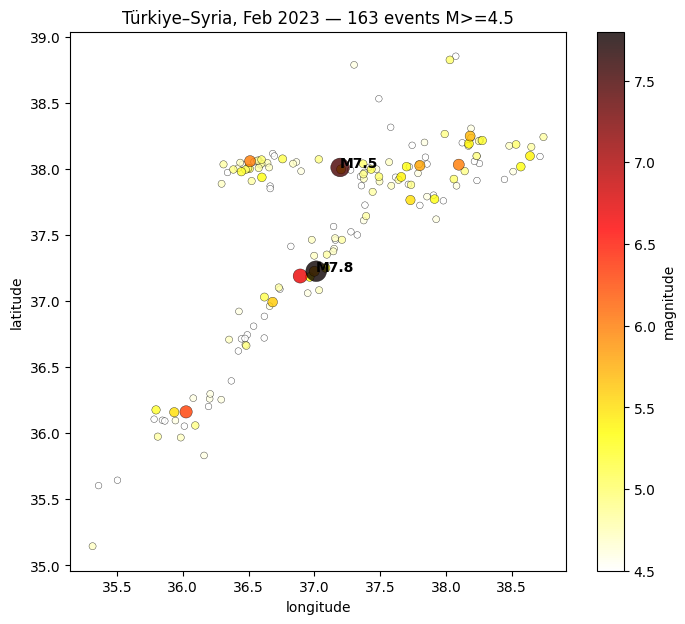

In [2]:
if quakes is not None and len(quakes):
    q = quakes.sort_values("magnitude")
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(q["longitude"], q["latitude"], c=q["magnitude"], cmap="hot_r",
                    s=2 ** (q["magnitude"]), edgecolor="k", linewidth=0.3, alpha=0.8)
    big = q[q["magnitude"] >= 7.0]
    for _, r in big.iterrows():
        ax.annotate(f"M{r.magnitude:.1f}", (r.longitude, r.latitude), fontsize=10, fontweight="bold")
    ax.set(xlabel="longitude", ylabel="latitude",
           title=f"Türkiye–Syria, Feb 2023 — {len(q)} events M>=4.5")
    fig.colorbar(sc, ax=ax, label="magnitude")
    plt.show()
else:
    print("no events to map")

## Aftershock sequence over time

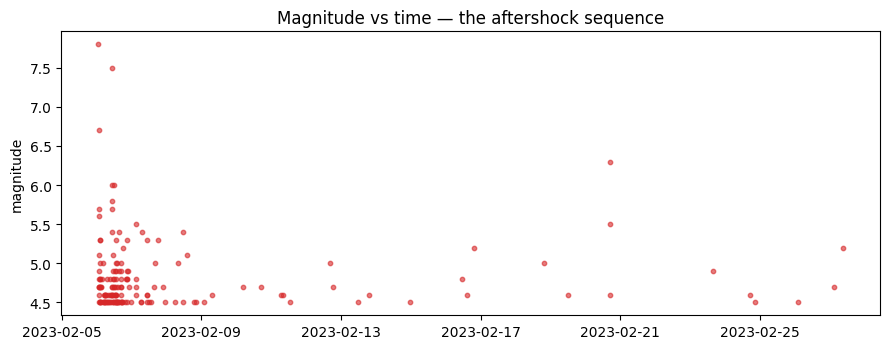

In [3]:
if quakes is not None and len(quakes):
    import pandas as pd
    t = pd.to_datetime(quakes["time"])
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.scatter(t, quakes["magnitude"], s=10, c="tab:red", alpha=0.6)
    ax.set_ylabel("magnitude"); ax.set_title("Magnitude vs time — the aftershock sequence")
    plt.tight_layout(); plt.show()
else:
    print("no events")